In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.constants import c
from astropy import constants as const
import astropy.units as u

In [2]:
C_IV_K = 1548.187e-8 #cm 
C_IV_H = 1550.772e-8
kk = 2795.528e-8
cc =c.to(u.cm / u.s).value
nu_K = cc / C_IV_K
nu_H  = cc / C_IV_H
v_th = 11.7673179819719e5 #cm/s
K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952
me = const.m_e.value

yy = np.arange(-1e4,1e4,10)


def VH(x,gamma_line,lines):
    del_lam_D = v_th / lines
    a = gamma_line / (4*np.pi*del_lam_D)
    dy = abs(yy[1]- yy[0])
    summ = np.zeros(len(x))
    for aa,bb in enumerate(x):
        for ii,jj in enumerate(yy):
            summ[aa] += np.exp(-jj**2) / ((bb-jj)**2+a**2) *dy
    return summ*a/np.pi

def change_x_to_lam(x,lines):
    del_lam_D = v_th / lines
    lam = np.zeros(len(xx))
    for ii, jj in enumerate(xx):
        lam[ii] = lines / (jj*v_th/cc + 1)
    return lam

NN = int(1e3)
xx = np.linspace(-5,5,NN)
v_k = VH(xx,K_gamma,C_IV_K)
lam_x = change_x_to_lam(xx,C_IV_K)*1e8

Text(0.5, 0, '$\\lambda [\\AA]$')

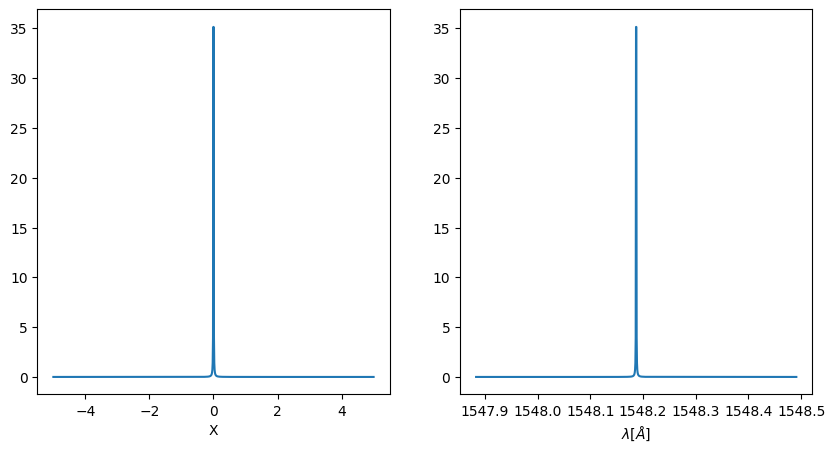

In [3]:
fig = plt.figure(1,figsize=(10,5))
plt.subplot(121)
plt.plot(xx,v_k)
plt.xlabel('X')

plt.subplot(122)
plt.plot(lam_x,v_k)
plt.xlabel(r'$\lambda [\AA]$')
# plt.xlim(1548.1,1548.3)


In [26]:
C_IV_K = 1548.187e-8 #cm 
C_IV_H = 1550.772e-8
kk = 2795.528e-8
cc =c.to(u.cm / u.s).value
nu_K = cc / C_IV_K
nu_H  = cc / C_IV_H
v_th = 11.7673179819719e5 #cm/s
K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952
me = const.m_e.value

NN = int(1e3)
yy = np.linspace(-5,5,NN)


def VH(x,v_th,gamma_line,lines):
    del_lam_D = v_th / lines
    a = gamma_line / (4*np.pi*del_lam_D)
    dy = abs(yy[1]- yy[0])
    summ = np.zeros(len(x))
    for aa,bb in enumerate(x):
        for ii,jj in enumerate(yy):
            summ[aa] += np.exp(-jj**2) / ((bb-jj)**2+a**2) *dy
    return summ*a/np.pi

def change_x_to_lam(x,lines):
    del_lam_D = v_th / lines
    lam = np.zeros(len(xx))
    for ii, jj in enumerate(xx):
        lam[ii] = lines / (jj*v_th/cc + 1)
    return lam

NN = int(1e3)
xx = np.linspace(-5,5,NN)
v_k = VH(xx,v_th,K_gamma,C_IV_K)
lam_x = change_x_to_lam(xx,C_IV_K)*1e8

3.39e+13


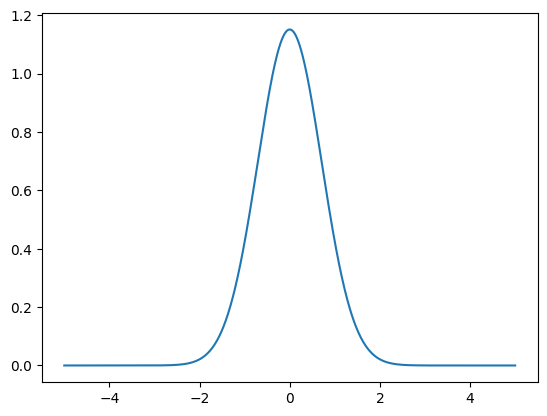

In [29]:
def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)
print("{:.2e}".format(N_CIV_0))

def tau(sig_c, x):
    return sig_c * x
rr = np.arange(12, 18, 1)
ee = [0]
em = [1]
atom = [13,20,32,50,79]
vran_0 = np.arange(200,2100,100)
# vran_1 = np.arange(1000,3000,500)
# vran = np.append(vran_0,vran_1)
vran = np.append(118,vran_0)

rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

sigma_Lya, sigma_CIV, N_CIV_0 = CIV(1e5)

total_N_c = 3.39e12
tau_0 = tau(sigma_CIV,total_N_c)
v_k = VH(xx,v_th,K_gamma,C_IV_K)
tau = tau_0*v_k
plt.plot(xx,tau)

In [153]:
NN = int(1e4)
xx = np.linspace(-3, 3, NN)
yy = np.linspace(-6, 6, NN)

def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)

def Voigt(x,v_th,gamma_line, lines):
    del_lam_D = v_th / lines
    a = gamma_line / (4 * np.pi * del_lam_D)
    dy = np.abs(yy[1] - yy[0])
    
    # Broadcasting and vectorized computation
    qq_minus_yy_squared = (x[:, np.newaxis] - yy)**2
    exp_neg_yy_squared = np.exp(-yy**2)
    
    summ = np.sum(exp_neg_yy_squared * dy / (qq_minus_yy_squared + a**2), axis=1)
    
    return summ * a / np.pi

def tau(sig_c, x):
    return sig_c * x

def N_esc_scat(C_iv_N ,v_th_1,N):
    # C_iv_N = 2e13
    # total_tau = np.zeros((len(C_iv_N), NN))

    # 벡터화된 tau 및 Voigt 프로파일 계산
    Voigt_profile = Voigt(xx,v_th_1,K_gamma, C_IV_K)
    tau_profile = tau(sig_c, C_iv_N) * Voigt_profile

    # x_0 계산
    # x_0 = np.zeros(len(C_iv_N))
    # for ii, jj in enumerate(C_iv_N):
    x_p = np.where(np.diff(np.sign(1 - tau_profile)))[0]
    x_0= xx[x_p].max() if x_p.size > 0 else 0

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s


    return tau_profile, V_del_peak , Voigt_profile


11.601382204848388


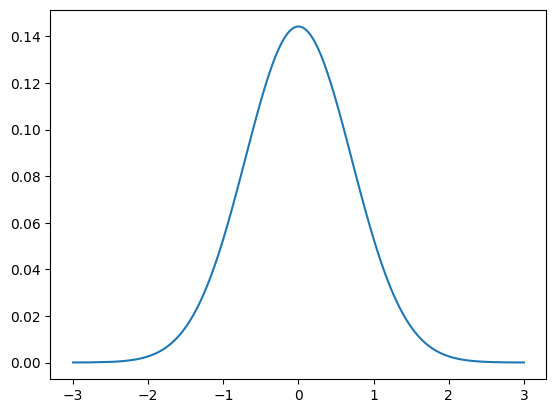

In [160]:
C_iv_N= 3e14
aa,bb,cc =N_esc_scat(C_iv_N,v_th*10,NN)
plt.plot(xx,cc)
print(bb[0])
# plt.plot(xx,cc,'ro')

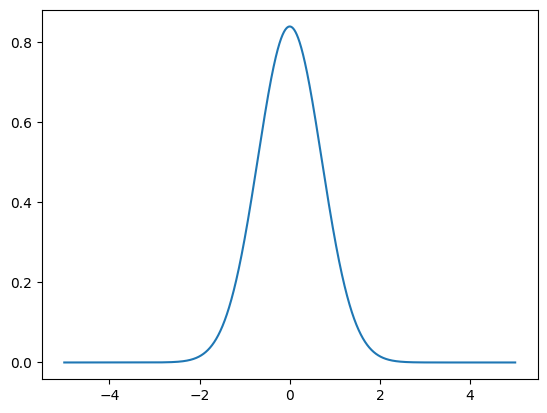